In [1]:
import os
import sys
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

import torch

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch.autograd import Variable
from classes.classifier import VocalClassifier
from classes.recording import Recording
from classes.list_of_vocals import ListOfVocals
from classes.vocal import Vocal

In [4]:
recording = np.load('/Users/gustavo/Documents/git/vocalpy/audios/audio_example_outputs/recording.vocalpy', allow_pickle=True)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/gustavo/Documents/git/vocalpy/audios/audio_example_outputs/recording.vocalpy'

In [28]:
path_to_spectrogram = '../audios/example_outputs/spectrogram'
ClassClassifier = VocalClassifier(type='class', path_to_spectrograms=recording.spectrogram_dir)
predictions = ClassClassifier.classify_list_of_vocals(recording.list_of_vocals)

In [29]:
a = recording.list_of_vocals

In [30]:
for idx, vocal in enumerate(a.vocals_in_recording):
    preds = torch.tensor(predictions[idx])
    top1, top2 = preds.topk(2).indices.numpy()
    print(ClassClassifier.classes[top1])
    print(ClassClassifier.classes[top2])
    print("--")

up_fm
chevron
--
up_fm
two_steps
--
step_up
two_steps
--
short
flat
--
step_up
down_fm
--
short
flat
--
short
up_fm
--
short
flat
--
short
flat
--
short
flat
--
flat
short
--
down_fm
step_down
--
up_fm
chevron
--
step_up
down_fm
--
up_fm
short
--
up_fm
flat
--
up_fm
step_up
--
up_fm
step_down
--
up_fm
step_up
--
up_fm
step_up
--
rev_chevron
down_fm
--
short
flat
--
rev_chevron
two_steps
--
short
down_fm
--
short
up_fm
--
short
flat
--
down_fm
step_down
--
step_up
down_fm
--
flat
step_up
--
flat
up_fm
--
up_fm
short
--
short
flat
--
short
flat
--
two_steps
mult_steps
--
up_fm
flat
--
up_fm
step_up
--
rev_chevron
step_up
--
step_up
down_fm
--
down_fm
step_up
--
down_fm
rev_chevron
--
down_fm
step_down
--
down_fm
step_down
--
down_fm
step_down
--
down_fm
step_down
--
down_fm
step_down
--
up_fm
step_up
--
two_steps
step_up
--
down_fm
step_down
--
down_fm
step_down
--
short
down_fm
--
down_fm
step_down
--
short
up_fm
--
rev_chevron
down_fm
--
chevron
flat
--
up_fm
chevron
--
up_fm
short
--


In [32]:
a.vocals_in_recording[1].probabilities

In [59]:
for idx in range(0,3):
    probabilities = predictions[idx]

    # -- convert numpy to torch, to use TopK function
    preds = torch.tensor(predictions[idx])
    # -- get top2 probabilities and their class names
    top1, top2 = preds.topk(2).indices.numpy()
    top1 = ClassClassifier.classes[top1]
    top2 = ClassClassifier.classes[top2]

TypeError: iteration over a 0-d array

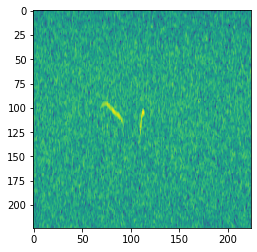

In [41]:
plt.imshow(image[0,0,:,:])

tensor([4.8890e-04, 2.7020e-05, 2.6921e-06, 5.8057e-03, 3.2101e-07, 5.3260e-03,
        3.1274e-03, 1.8511e-03, 6.1265e-03, 1.0631e-03, 9.7618e-01])

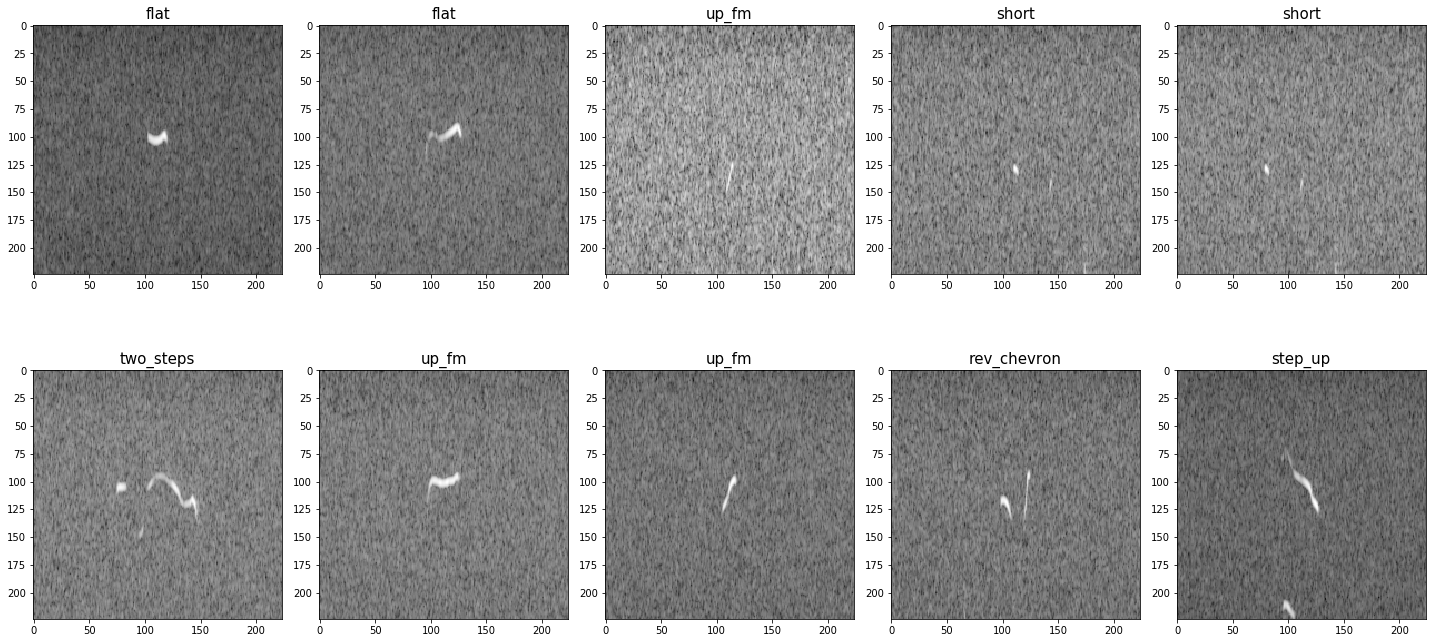

In [3]:
for i in range(0,30):
    # -- first few examples are noise, for the noise CNN demo
    # -- skip them
    dataiter.next()

fig, axs = plt.subplots(2, 5, figsize=(20, 10))    
for ax in axs.reshape(-1):
    image = dataiter.next()
    image = image.to(ClassClassifier.device)
    image = Variable(image)
    score = ClassClassifier.model(image)
    _, predicted = torch.max(score.data, 1)
    ax.imshow(image.cpu().numpy()[0,0,:,:], cmap='gray')
    title = ClassClassifier.classes[predicted.numpy()[0]]
    ax.set_title(title, size=15)

fig.tight_layout()
plt.show()